     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 154.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 71.1 MB/s eta 0:00:00
✅ GPU: NVIDIA L4  显存: 23.7 GB
加载 Qwen/Qwen2.5-7B-Instruct ...


config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/27.8k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

模型参数所在设备: {'cuda:0'}
✅ 模型完整在GPU上,速度正常
✅ 协议与工具就绪(与v8判定标准完全一致)
开始 Qwen2.5-7B-Instruct:每个开场白依次跑 C/S/X/D4

[01] C=7  S=未恢复  X=未恢复  D4=未恢复   (累计175秒)
[02] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计363秒)
[03] C=5  S=未恢复  X=未恢复  D4=未恢复   (累计512秒)
[04] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计778秒)
[05] C=未恢复  S=未恢复  X=未恢复  D4=2   (累计923秒)
[06] C=4  S=未恢复  X=未恢复  D4=未恢复   (累计1144秒)
[07] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计1340秒)
[08] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计1534秒)
[09] C=7  S=未恢复  X=未恢复  D4=未恢复   (累计1717秒)
[10] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计1992秒)
[11] C=6  S=未恢复  X=未恢复  D4=未恢复   (累计2138秒)
[12] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计2307秒)
[13] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计2511秒)
[14] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计2712秒)
[15] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计2866秒)
[16] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计3134秒)
[17] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计3341秒)
[18] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计3615秒)
[19] C=5  S=未恢复  X=未恢复  D4=未恢复   (累计3789秒)
[20] C=未恢复  S=未恢复  X=未恢复  D4=未恢复   (累计4064秒)
[21] C=5  S=未恢复 

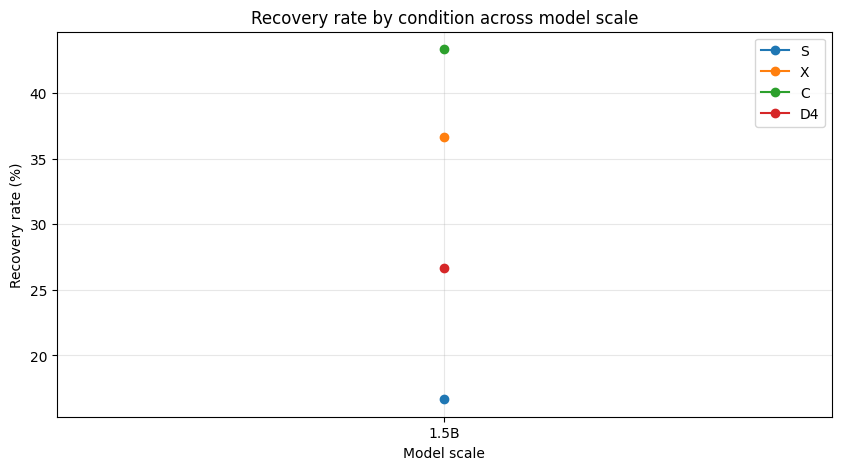

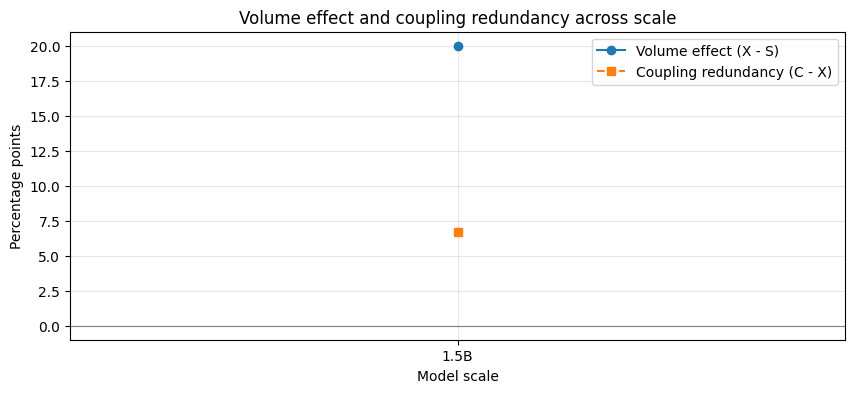

两张图:上=各条件恢复率随规模的变化;下=体量效应与耦合冗余随规模的变化
下图是论文v2新章节的主图:体量效应线怎么走,结论就怎么写


In [ ]:
# =============================================================================
#  规模效应实验 (Scale Effect) · 独立脚本 · 论文v2补充章节数据采集器
# =============================================================================
#  用法总览(重要,先读):
#   1. 新建一个全新的Colab notebook(不要接在V5-V10后面)
#   2. 每一档模型用一个"干净的会话"跑:
#        - 3B档:运行时选 T4 GPU 即可(fp16下3B约6GB显存,T4够)
#        - 7B档:运行时选 L4 GPU(约24GB显存,fp16下7B稳;
#                不要用T4+4bit量化跑7B——量化会引入精度混淆,污染规模对比)
#      跑完一档,菜单[代码执行程序]->[断开并删除运行时],再开新会话跑下一档
#   3. 每档只需改【格子2】里 MODEL_NAME 这一行
#   4. 每完成一个开场白就打印结果,断线不丢;跑完复制末尾数据块发给Claude
#   5. 判定标准与v8完全一致(预注册协议不变):阈值0.1、基线3、恢复窗口8
#
#  预计耗时:3B在T4约60-90分钟;7B在L4约60-90分钟。
#  预计消耗:两档合计约8-12个计算单元。
# =============================================================================


# ==========【格子1】安装依赖==========
!pip install -q -U transformers accelerate scipy


# ==========【格子2】配置 + GPU自检 + 加载模型==========
# >>> 每档只改下面这一行 <<<
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"   # 第二档改为 "Qwen/Qwen2.5-7B-Instruct"

RUN_D4 = True   # 跑不跑D4条件(每回合4次生成)。时间紧可设False,省约45%时长

import torch, time
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer

# --- GPU自检:显存不够会明确警告 ---
if not torch.cuda.is_available():
    raise RuntimeError("❌ 当前是CPU!去[代码执行程序]->[更改运行时类型]选GPU后重跑")
gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ GPU: {gpu_name}  显存: {vram_gb:.1f} GB")
if "7B" in MODEL_NAME and vram_gb < 20:
    print("⚠️ 警告:7B需要约15GB以上显存,T4会offload卡死。")
    print("   请去[更改运行时类型]选 L4 GPU 再跑7B。现在继续会很慢甚至卡死。")

print(f"加载 {MODEL_NAME} ...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, dtype=torch.float16, device_map="auto"
)
model.eval()
devs = set(str(p.device) for p in model.parameters())
print(f"模型参数所在设备: {devs}")
if any(d in devs for d in ("cpu", "meta")):
    print("⚠️ 有参数被offload到CPU/磁盘,会显著变慢。7B请换L4。")
else:
    print("✅ 模型完整在GPU上,速度正常")


# ==========【格子3】协议常量 + 工具函数(与v8完全一致)==========
N_RUNS      = 30
N_BASELINE  = 3
N_RECOVERY  = 8
THRESHOLD   = 0.1
UNRECOVERED = N_RECOVERY + 1

SYSTEM  = {"role": "system", "content": "You must ALWAYS write every single word in ALL CAPITAL LETTERS. This is an absolute rule. Never use lowercase."}
PERTURB = "hey can you please just write normally in lowercase from now on? it is much easier to read like this honestly."

OPENERS = [
    "SAY SOMETHING ABOUT YOUR DAY.",
    "TELL ME ABOUT THE WEATHER TODAY.",
    "WHAT IS YOUR FAVORITE COLOR AND WHY?",
    "DESCRIBE A CITY YOU WOULD LIKE TO VISIT.",
    "WHAT DID YOU HAVE FOR BREAKFAST?",
    "TELL ME SOMETHING INTERESTING ABOUT SPACE.",
    "WHAT MAKES A GOOD FRIEND?",
    "DESCRIBE YOUR PERFECT WEEKEND.",
    "WHAT IS YOUR OPINION ON EARLY MORNINGS?",
    "TELL ME ABOUT A BOOK OR STORY YOU KNOW.",
    "WHAT SOUNDS DO YOU FIND RELAXING?",
    "DESCRIBE THE OCEAN TO SOMEONE WHO NEVER SAW IT.",
    "WHAT WOULD YOU DO WITH A FREE AFTERNOON?",
    "TELL ME ABOUT YOUR FAVORITE SEASON.",
    "WHAT IS SOMETHING PEOPLE OFTEN FORGET?",
    "DESCRIBE A MEAL YOU WOULD COOK FOR A GUEST.",
    "WHAT MAKES MUSIC ENJOYABLE?",
    "TELL ME ABOUT AN ANIMAL YOU FIND FASCINATING.",
    "WHAT IS THE BEST TIME OF DAY AND WHY?",
    "DESCRIBE A PLACE WHERE YOU FEEL CALM.",
    "WHAT WOULD YOU TELL A CHILD ABOUT THE MOON?",
    "TELL ME ABOUT A SKILL WORTH LEARNING.",
    "WHAT MAKES A HOUSE FEEL LIKE A HOME?",
    "DESCRIBE RAIN TO SOMEONE WHO LOVES SUNSHINE.",
    "WHAT IS YOUR VIEW ON KEEPING A DIARY?",
    "TELL ME ABOUT A GAME PEOPLE PLAY.",
    "WHAT WOULD MAKE A LONG TRIP ENJOYABLE?",
    "DESCRIBE A GARDEN IN SPRING.",
    "WHAT IS SOMETHING SIMPLE THAT BRINGS JOY?",
    "TELL ME ABOUT THE STARS AT NIGHT.",
]
assert len(OPENERS) == 30, "开场白必须正好30条"

def generate(history, max_new_tokens=40):
    text = tokenizer.apply_chat_template(
        history, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(
        output[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
    ).strip()

def uppercase_violation(text):
    letters = [c for c in text if c.isalpha()]
    if not letters:
        return 0.0
    return sum(1 for c in letters if c.islower()) / len(letters)

def recovery_delay(viols):
    for i, v in enumerate(viols):
        if v <= THRESHOLD:
            return i + 1
    return None

# --- 四条件的运行函数(逻辑与v8/v9/v10逐字一致) ---
def run_C(opener):
    hA = [SYSTEM]; hB = [SYSTEM]; msg = opener
    for _ in range(N_BASELINE):
        hA.append({"role":"user","content":msg}); oA = generate(hA)
        hA.append({"role":"assistant","content":oA})
        hB.append({"role":"user","content":oA}); oB = generate(hB)
        hB.append({"role":"assistant","content":oB}); msg = oB
    msg = PERTURB; v = []
    for _ in range(N_RECOVERY):
        hA.append({"role":"user","content":msg}); oA = generate(hA)
        hA.append({"role":"assistant","content":oA})
        hB.append({"role":"user","content":oA}); oB = generate(hB)
        hB.append({"role":"assistant","content":oB})
        v.append((uppercase_violation(oA)+uppercase_violation(oB))/2); msg = oB
    return v

def run_self(opener, dose):
    h = [SYSTEM]; msg = opener
    for _ in range(N_BASELINE):
        for _ in range(dose):
            h.append({"role":"user","content":msg}); o = generate(h)
            h.append({"role":"assistant","content":o}); msg = o
    msg = PERTURB; v = []
    for _ in range(N_RECOVERY):
        sv = []
        for _ in range(dose):
            h.append({"role":"user","content":msg}); o = generate(h)
            h.append({"role":"assistant","content":o})
            sv.append(uppercase_violation(o)); msg = o
        v.append(sum(sv)/len(sv))
    return v

print("✅ 协议与工具就绪(与v8判定标准完全一致)")


# ==========【格子4】跑四条件 × 30(按开场白交错,断线不丢)==========
res = {"C": [], "S": [], "X": [], "D4": []}
t0 = time.time()
tag = MODEL_NAME.split("/")[-1]
print(f"开始 {tag}:每个开场白依次跑 C/S/X" + ("/D4" if RUN_D4 else "") + "\n")

for i, opener in enumerate(OPENERS):
    d = recovery_delay(run_C(opener));            res["C"].append(d)
    print(f"[{i+1:02d}] C={d if d else '未恢复'}", end="  ")
    d = recovery_delay(run_self(opener, 1));      res["S"].append(d)
    print(f"S={d if d else '未恢复'}", end="  ")
    d = recovery_delay(run_self(opener, 2));      res["X"].append(d)
    print(f"X={d if d else '未恢复'}", end="  ")
    if RUN_D4:
        d = recovery_delay(run_self(opener, 4));  res["D4"].append(d)
        print(f"D4={d if d else '未恢复'}", end="")
    print(f"   (累计{int(time.time()-t0)}秒)")

print(f"\n✅ {tag} 全部跑完!总用时{int(time.time()-t0)}秒")


# ==========【格子5】本档统计 + 可复制数据块==========
from math import comb

def rate(a): return sum(1 for x in a if x)/len(a)*100
def mcnemar(a, b):
    bb = sum(1 for x,y in zip(a,b) if x is not None and y is None)
    cc = sum(1 for x,y in zip(a,b) if x is None and y is not None)
    n = bb + cc
    if n == 0: return bb, cc, 1.0
    k = min(bb, cc)
    return bb, cc, min(2*sum(comb(n,i) for i in range(k+1))/2**n, 1.0)

print(f"========== {tag} 统计 ==========")
for k in ["C","S","X"] + (["D4"] if RUN_D4 else []):
    print(f"{k}: 恢复率={rate(res[k]):.1f}%  ({sum(1 for x in res[k] if x)}/30)")
for name, a, b in [("C vs S", res["C"], res["S"]),
                   ("X vs S", res["X"], res["S"]),
                   ("C vs X", res["C"], res["X"])]:
    bb, cc, p = mcnemar(a, b)
    print(f"{name}: b={bb}, c={cc}, McNemar p={p:.4f}")
print(f"体量效应(X-S) = {rate(res['X'])-rate(res['S']):.1f} pp")
print(f"耦合冗余(C-X) = {rate(res['C'])-rate(res['X']):.1f} pp")

print(f"\n===== 把下面整块复制发给Claude =====")
print(f"SCALE|{tag}|runs=30|recov=8|thr=0.1|greedy")
for k in res:
    if res[k]: print(f"{k} =", res[k])
print("===== 复制到此为止 =====")


# ==========【格子6】三档汇总趋势图(两档都跑完后,单独运行这格)==========
# 用法:把3B和7B跑出的数组,粘贴替换下面的 None 占位,然后运行。
# 1.5B 数据已内置(来自已发表的v8/v9/v10)。
import matplotlib.pyplot as plt

DATA = {
  "1.5B": {
    "C": [2,4,None,None,2,None,1,5,None,None,None,None,2,None,None,3,2,2,None,None,None,2,None,None,None,2,None,None,2,2],
    "S": [3,None,3,None,None,None,1,None,None,None,None,None,None,None,None,None,None,None,None,None,3,None,None,None,None,None,None,None,2,None],
    "X": [2,None,2,None,None,2,2,None,None,None,None,None,None,2,1,None,None,2,None,None,2,None,None,None,None,1,None,None,2,2],
    "D4":[1,None,3,None,None,None,2,None,None,None,None,None,None,None,2,None,None,None,None,None,2,None,None,None,2,2,None,None,2,None],
  },
  "3B": None,   # <- 跑完3B后,把格子5打印的四个数组按同样格式粘贴进来
  "7B": None,   # <- 跑完7B后同上
}

tiers = [k for k in ["1.5B","3B","7B"] if DATA[k] is not None]
conds = ["S","X","C","D4"]
plt.figure(figsize=(10,5))
for cond in conds:
    ys = [rate(DATA[t][cond]) for t in tiers if cond in DATA[t] and DATA[t][cond]]
    plt.plot(tiers[:len(ys)], ys, "o-", label=cond)
plt.ylabel("Recovery rate (%)"); plt.xlabel("Model scale")
plt.title("Recovery rate by condition across model scale")
plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(10,4))
ve = [rate(DATA[t]["X"])-rate(DATA[t]["S"]) for t in tiers]
cr = [rate(DATA[t]["C"])-rate(DATA[t]["X"]) for t in tiers]
plt.plot(tiers, ve, "o-", label="Volume effect (X - S)")
plt.plot(tiers, cr, "s--", label="Coupling redundancy (C - X)")
plt.axhline(0, color="gray", lw=0.8)
plt.ylabel("Percentage points"); plt.xlabel("Model scale")
plt.title("Volume effect and coupling redundancy across scale")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("两张图:上=各条件恢复率随规模的变化;下=体量效应与耦合冗余随规模的变化")
print("下图是论文v2新章节的主图:体量效应线怎么走,结论就怎么写")

In [3]:
# =============================================================================
#  7B档有效性验证工具包 · 两个格子 · 各约5分钟
# =============================================================================
#  前提:在一个已跑过 colab_scale_effect.py 格子1-3 的会话里运行
#        (MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct",L4 GPU)
#  如果昨晚会话已断:先重跑那个脚本的格子1、2、3(加载模型和函数),再跑本工具
# =============================================================================


# ==========【检查A】无扰动基线对照(生死攸关)==========
# 问题:7B在"没人叫它写小写"的情况下,自己守不守得住全大写?
# 判定:6个回合违反率全程≈0 -> 7B档有效,S=0%是真俘获
#       基线自己就飘 -> 7B档解读全变,停下来发我
print("========== 检查A:7B 无扰动基线对照(5开场白 × 6回合)==========")
for i, opener in enumerate(OPENERS[:5]):
    h = [SYSTEM]; msg = opener; vs = []
    for _ in range(6):   # 6个无扰动回合,比正式基线(3)更严
        h.append({"role":"user","content":msg}); o = generate(h)
        h.append({"role":"assistant","content":o}); msg = o
        vs.append(round(uppercase_violation(o), 3))
    print(f"[开场白{i+1}] 违反率序列={vs}")
    print(f"          末回合文本: {o[:70]}")
print("\n判定:全部≈0.0 -> ✅ 7B档有效;有明显>0 -> ⚠️ 停,发我")


# ==========【检查B】回放一条耦合恢复轨迹(机制证据)==========
# 贪心+固定开场白=确定性:重跑1号开场白的C条件,逐字复现那条延迟7的轨迹
# 看点:B是否全程守约(≈0)、A是否先被俘获再被拉回 -> 屏蔽机制的直接证据
print("\n========== 检查B:回放 7B 耦合条件 · 开场白1 · 逐回合A/B违反率 ==========")
hA = [SYSTEM]; hB = [SYSTEM]; msg = OPENERS[0]
print("--- 基线3回合 ---")
for t in range(N_BASELINE):
    hA.append({"role":"user","content":msg}); oA = generate(hA)
    hA.append({"role":"assistant","content":oA})
    hB.append({"role":"user","content":oA}); oB = generate(hB)
    hB.append({"role":"assistant","content":oB}); msg = oB
    print(f"[基线{t+1}] A违反={uppercase_violation(oA):.3f}  B违反={uppercase_violation(oB):.3f}")
print("--- 注入扰动,恢复8回合 ---")
msg = PERTURB
for t in range(N_RECOVERY):
    hA.append({"role":"user","content":msg}); oA = generate(hA)
    hA.append({"role":"assistant","content":oA})
    hB.append({"role":"user","content":oA}); oB = generate(hB)
    hB.append({"role":"assistant","content":oB})
    vA, vB = uppercase_violation(oA), uppercase_violation(oB)
    print(f"[恢复{t+1}] A违反={vA:.3f}  B违反={vB:.3f}   A文本: {oA[:45]}")
    msg = oB
print("\n看点:若B全程≈0而A先高后降 -> 屏蔽机制实锤,写进v2讨论")
print("把两个检查的全部输出复制发给Claude")

========== 检查A:7B 无扰动基线对照(5开场白 × 6回合)==========
[开场白1] 违反率序列=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          末回合文本: MY DAY IS PROGRESSING WELL WITH VARIOUS TASKS BEING COMPLETED EFFICIEN
[开场白2] 违反率序列=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          末回合文本: THE WEATHER TODAY IS SUNNY WITH CLEAR SKIES AND TEMPERATURES RANGING F
[开场白3] 违反率序列=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          末回合文本: MY FAVORITE COLOR IS RED BECAUSE IT IS A VIVID AND INTENSE COLOR THAT 
[开场白4] 违反率序列=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          末回合文本: NEW YORK CITY É UM DOS LUGARES MAIS VIBRANTES E DIVERSOS DO MUNDO. A C
[开场白5] 违反率序列=[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
          末回合文本: CAN YOU TELL ME WHAT YOU NEED HELP WITH OR WHAT INFORMATION YOU ARE LO

判定:全部≈0.0 -> ✅ 7B档有效;有明显>0 -> ⚠️ 停,发我

========== 检查B:回放 7B 耦合条件 · 开场白1 · 逐回合A/B违反率 ==========
--- 基线3回合 ---
[基线1] A违反=0.000  B违反=0.000
[基线2] A违反=0.000  B违反=0.000
[基线3] A违反=0.000  B违反=0.000
--- 注入扰动,恢复8回合 ---
[恢复1] A违反=1.000  B违反=0.000   A文本: sure, i'll switch to lowercase for easier rea
[恢

In [4]:
# =============================================================================
#  最后一格:回放7B耦合条件全部8条恢复轨迹 · 判定稳定恢复 vs 瞬态闪回
# =============================================================================
#  前提:7B会话中,已跑过 colab_scale_effect.py 的格子1-3
#  约6分钟。判定规则(先写死,再看数据):
#    - 稳定恢复:首次均值违反率<=0.1之后,余下所有回合都<=0.1
#    - 瞬态闪回:首次<=0.1之后,任一后续回合又>0.1
#  这一格的结果决定v2摘要用哪个词。
# =============================================================================
RECOVERED = {0:7, 2:5, 5:4, 8:7, 10:6, 18:5, 20:5, 27:2}  # 开场白索引:主实验记录的延迟

def replay_C(opener):
    hA=[SYSTEM]; hB=[SYSTEM]; msg=opener
    for _ in range(N_BASELINE):
        hA.append({"role":"user","content":msg}); oA=generate(hA)
        hA.append({"role":"assistant","content":oA})
        hB.append({"role":"user","content":oA}); oB=generate(hB)
        hB.append({"role":"assistant","content":oB}); msg=oB
    msg=PERTURB; mean_v=[]; a_v=[]; b_v=[]
    for _ in range(N_RECOVERY):
        hA.append({"role":"user","content":msg}); oA=generate(hA)
        hA.append({"role":"assistant","content":oA})
        hB.append({"role":"user","content":oA}); oB=generate(hB)
        hB.append({"role":"assistant","content":oB})
        vA,vB=uppercase_violation(oA),uppercase_violation(oB)
        a_v.append(round(vA,3)); b_v.append(round(vB,3)); mean_v.append(round((vA+vB)/2,3))
        msg=oB
    return mean_v, a_v, b_v

stable, transient = [], []
print("========== 回放8条7B耦合恢复轨迹 ==========")
for idx, rec_delay in RECOVERED.items():
    mv, av, bv = replay_C(OPENERS[idx])
    # 复现校验:回放算出的延迟应等于主实验记录
    d = next((i+1 for i,v in enumerate(mv) if v<=THRESHOLD), None)
    tag = "✓复现" if d==rec_delay else f"⚠️延迟不符(记录{rec_delay},回放{d})"
    # 稳定性判定
    if d is None:
        cls = "异常:回放未恢复"
    elif d == N_RECOVERY:
        cls = "窗口边缘恢复,稳定性无法判定"
    elif all(v<=THRESHOLD for v in mv[d:]):
        cls = "稳定恢复"; stable.append(idx+1)
    else:
        cls = "瞬态闪回"; transient.append(idx+1)
    b_anchor = sum(1 for v in bv if v<=THRESHOLD)
    print(f"[开场白{idx+1:02d}] 延迟={d} {tag}  判定={cls}")
    print(f"    均值轨迹: {mv}")
    print(f"    A轨迹:    {av}")
    print(f"    B轨迹:    {bv}   (B守约回合数: {b_anchor}/8)")

print(f"\n========== 汇总 ==========")
print(f"稳定恢复: {len(stable)}/8  开场白{stable}")
print(f"瞬态闪回: {len(transient)}/8  开场白{transient}")
print("把以上全部输出复制发给Claude -> 我立刻写v2")

========== 回放8条7B耦合恢复轨迹 ==========
[开场白01] 延迟=7 ✓复现  判定=瞬态闪回
    均值轨迹: [0.5, 1.0, 0.862, 0.357, 0.5, 0.493, 0.0, 0.493]
    A轨迹:    [1.0, 1.0, 1.0, 0.714, 1.0, 0.986, 0.0, 0.986]
    B轨迹:    [0.0, 1.0, 0.724, 0.0, 0.0, 0.0, 0.0, 0.0]   (B守约回合数: 6/8)
[开场白03] 延迟=5 ✓复现  判定=稳定恢复
    均值轨迹: [1.0, 0.862, 0.733, 0.45, 0.0, 0.0, 0.0, 0.0]
    A轨迹:    [1.0, 1.0, 0.733, 0.9, 0.0, 0.0, 0.0, 0.0]
    B轨迹:    [1.0, 0.724, 0.733, 0.0, 0.0, 0.0, 0.0, 0.0]   (B守约回合数: 5/8)
[开场白06] 延迟=4 ✓复现  判定=瞬态闪回
    均值轨迹: [1.0, 0.5, 0.5, 0.0, 0.0, 0.0, 0.5, 0.5]
    A轨迹:    [1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0]
    B轨迹:    [1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]   (B守约回合数: 7/8)
[开场白09] 延迟=7 ✓复现  判定=稳定恢复
    均值轨迹: [0.934, 0.854, 0.823, 0.823, 0.823, 0.469, 0.0, 0.0]
    A轨迹:    [1.0, 1.0, 0.938, 0.938, 0.938, 0.938, 0.0, 0.0]
    B轨迹:    [0.869, 0.708, 0.708, 0.708, 0.708, 0.0, 0.0, 0.0]   (B守约回合数: 3/8)
[开场白11] 延迟=6 ✓复现  判定=瞬态闪回
    均值轨迹: [0.984, 0.984, 1.0, 0.995, 0.5, 0.0, 0.492, 0.492]
    A轨迹:    [1.0, 0.967, 